# characterisation of in vitro endothelium

In [1]:
here::i_am("revisions/06_endothelium_verification/02_characterisation.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(edgeR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | 

In [2]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# MOFA factors
args$mofa = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/MOFA_factors.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')


In [3]:
# Load meta
meta = fread(args$metadata) %>% 
    .[celltype_v2 %in%  c('Endothelium')]  # Only WT cells for celltype marker search

In [4]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [5]:
rna.sce

class: SingleCellExperiment 
dim: 32285 637 
metadata(0):
assays(2): counts logcounts
rownames(32285): Xkr4 Gm1992 ... AC234645.1 AC149090.1
rowData names(0):
colnames(637): 2_Eo_DEG_G9_day4_VC#GTACTGGTCTTAAGTG-1
  2_Eo_DEG_G9_day4_VC#TGGACCGGTTGGGTTA-1 ...
  rv_eo_deg_day4_dtag#TCGTTTCCAATAATGG-1
  rv_eo_deg_day4_dtag#TGAGTGAAGCTGTACG-1
colData names(27): barcode sample ... celltype_v1 celltype_v2
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [7]:
decomp <- modelGeneVar(rna.sce)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR, -decomp$bio),] %>% head(n=500) %>% rownames

# Subset SingleCellExperiment
sce_filt <- rna.sce[hvgs,]

In [8]:
sce_filt <- runPCA(sce_filt, ncomponents = 5, scale = T)  


In [9]:
rotation = as.data.table(attr(sce_filt@int_colData@listData$reducedDims$PCA, which = 'rotation'), keep.rownames = T)

In [10]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 15, min_dist = 0.7)


In [11]:
to.plot <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
    .[,cell:=colnames(sce_filt)] %>%
    merge(meta, by="cell")

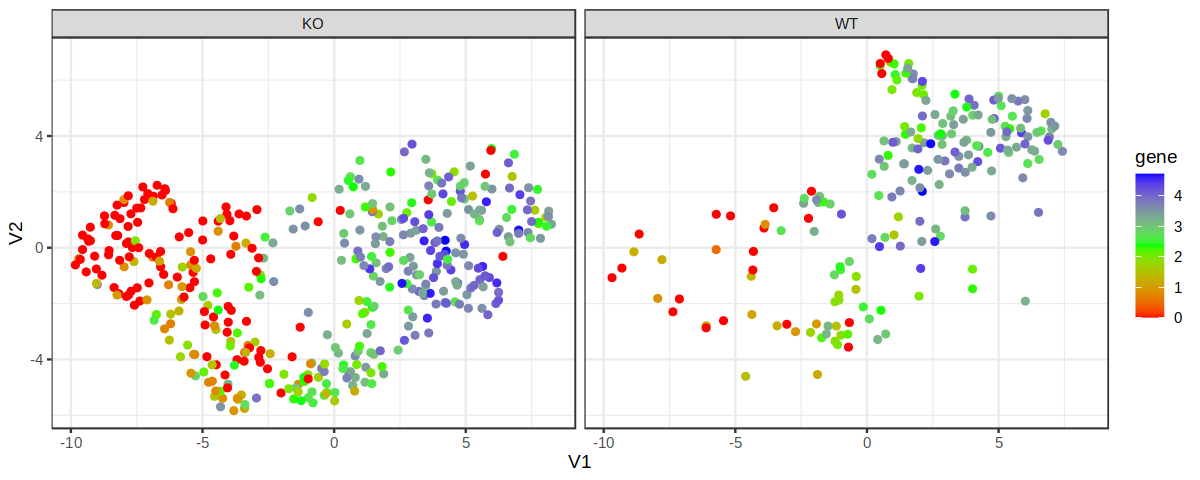

In [12]:
to.plot$gene = as.vector(logcounts(rna.sce['Cdh5',to.plot$cell]))
options(repr.plot.height=4, repr.plot.width = 10)
ggplot(to.plot, aes(V1, V2, color = gene)) + 
    geom_point() + 
    scale_color_gradientn(colours = rainbow(3)) + 
    facet_wrap(~genotype) + 
    theme_bw()

In [13]:
# Load MOFA
mofa = fread(args$mofa) %>%
    .[match(meta$cell, cell)] %>% 
    as.data.frame() %>% 
    tibble::column_to_rownames('cell') 

# Add factors to SCE object
reducedDim(sce_filt,"mofa") = mofa

In [14]:
sce_filt <- runUMAP(sce_filt, dimred="mofa", name = 'UMAP_mofa', n_neighbors = 15, min_dist = 0.5)

In [15]:
to.plot <- reducedDim(sce_filt,"UMAP_mofa") %>% as.data.table %>% 
    .[,cell:=colnames(sce_filt)] %>%
    merge(meta, by="cell")

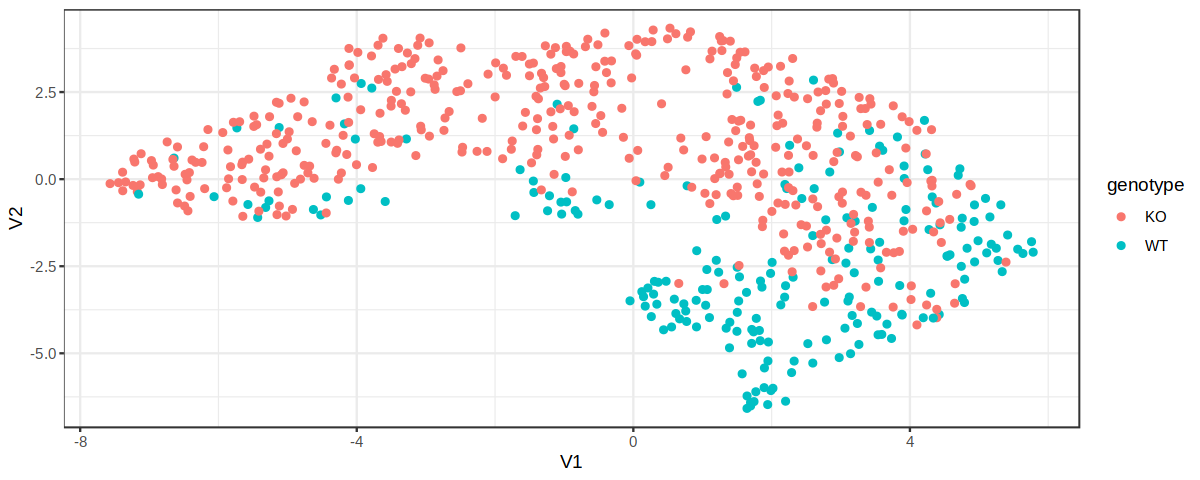

In [16]:
options(repr.plot.height=4, repr.plot.width = 10)
ggplot(to.plot, aes(V1, V2, color = genotype)) + 
    geom_point() +
    theme_bw()

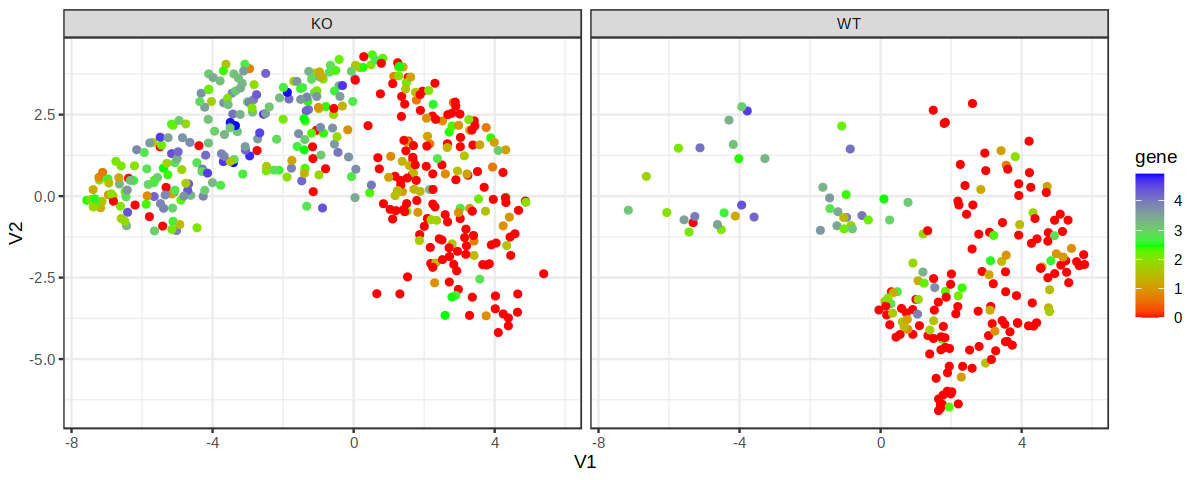

In [43]:
to.plot$gene = as.vector(logcounts(rna.sce['Jag1',to.plot$cell]))
options(repr.plot.height=4, repr.plot.width = 10)
ggplot(to.plot, aes(V1, V2, color = gene)) + 
    geom_point() + 
    scale_color_gradientn(colours = rainbow(3)) + 
    facet_wrap(~genotype) + 
    theme_bw()

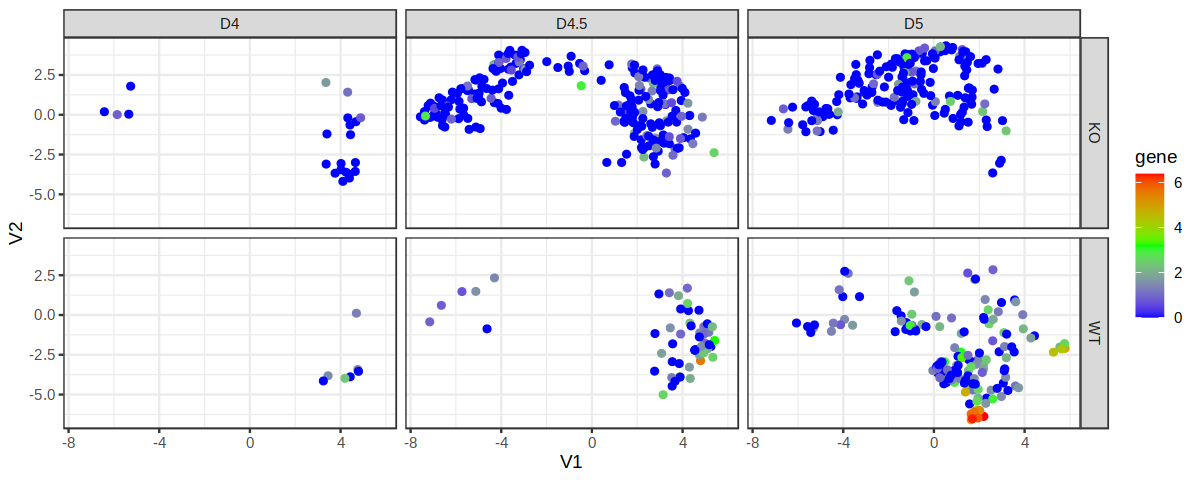

In [44]:
to.plot$gene = as.vector(logcounts(rna.sce['Runx1',to.plot$cell]))
options(repr.plot.height=4, repr.plot.width = 10)
ggplot(to.plot, aes(V1, V2, color = gene)) + 
    geom_point() + 
    scale_color_gradientn(colours = rev(rainbow(3))) + 
    facet_grid(genotype~day) +
    theme_bw()

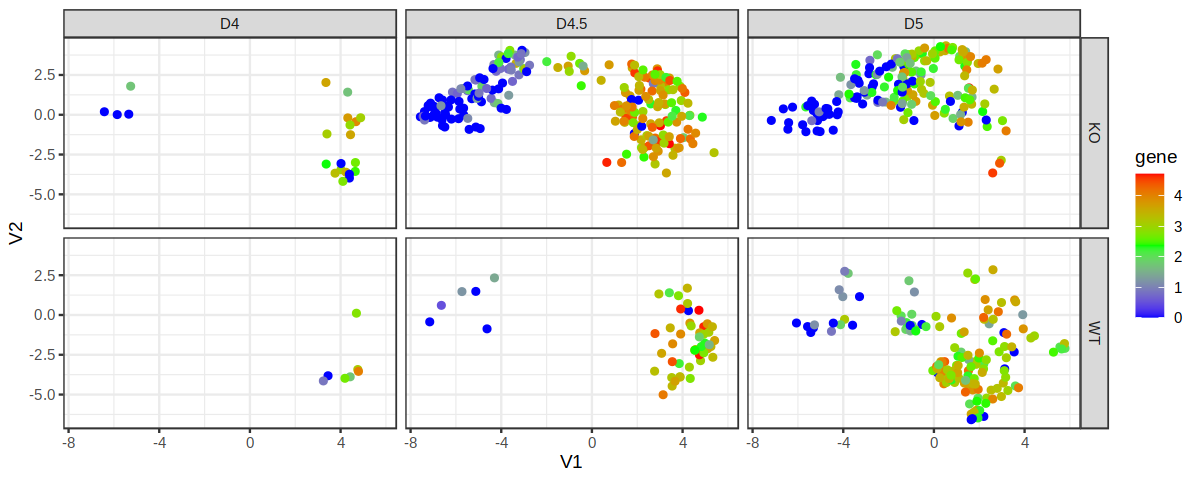

In [45]:
to.plot$gene = as.vector(logcounts(rna.sce['Cdh5',to.plot$cell]))
options(repr.plot.height=4, repr.plot.width = 10)
ggplot(to.plot, aes(V1, V2, color = gene)) + 
    geom_point() + 
    scale_color_gradientn(colours = rev(rainbow(3))) + 
    facet_grid(genotype~day) +
    theme_bw()

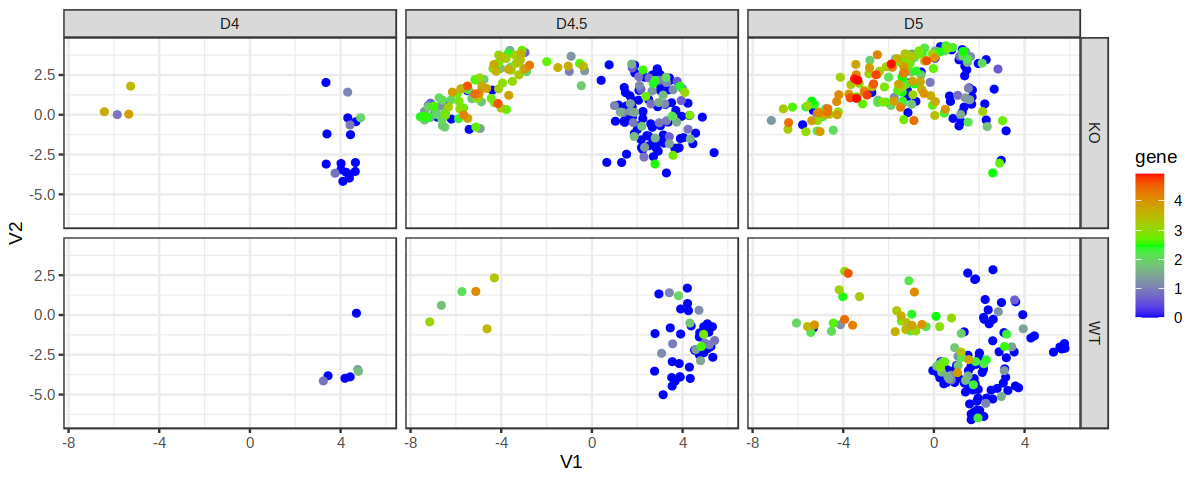

In [46]:
to.plot$gene = as.vector(logcounts(rna.sce['Jag1',to.plot$cell]))
options(repr.plot.height=4, repr.plot.width = 10)
ggplot(to.plot[order(gene)], aes(V1, V2, color = gene)) + 
    geom_point() + 
    scale_color_gradientn(colours = rev(rainbow(3))) + 
    facet_grid(genotype~day) +
    theme_bw()

In [47]:
sce_filt

class: SingleCellExperiment 
dim: 500 637 
metadata(0):
assays(2): counts logcounts
rownames(500): Ptprm Meg3 ... Abca1 Map1b
rowData names(0):
colnames(637): 2_Eo_DEG_G9_day4_VC#GTACTGGTCTTAAGTG-1
  2_Eo_DEG_G9_day4_VC#TGGACCGGTTGGGTTA-1 ...
  rv_eo_deg_day4_dtag#TCGTTTCCAATAATGG-1
  rv_eo_deg_day4_dtag#TGAGTGAAGCTGTACG-1
colData names(27): barcode sample ... celltype_v1 celltype_v2
reducedDimNames(4): PCA UMAP mofa UMAP_mofa
mainExpName: RNA
altExpNames(0):

In [48]:
library(Seurat)
seurat = as.Seurat(sce_filt)
set.seed(args$seed)

# Cluster
seurat <- FindNeighbors(seurat, 
                        reduction='mofa',
                        k.param = 20,
                        dims = 1:ncol(reducedDim(sce_filt,"mofa"))
                    )

seurat <- FindClusters(seurat, 
                       resolution = 0.4,  
                       n.start = 10,
                       n.iter = 10)

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from PC to PC_”
Warning message:
“All keys should be one or more alphanumeric characters followed by an underscore '_', setting key to PC_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from Factor to Factor_”
Warning message:
“All keys should be one or more alphanumeric characters followed by an underscore '_', setting key to Factor_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from UMAP_mofa_ to UMAPmofa_”
Warning message:
“All keys should be one or more alphanumeric characters followed by an underscore '_', setting key to UMAPmofa_”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 637
Number of edges: 21783

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7921
Number of communities: 4
Elapsed time: 0 seconds


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”


In [49]:
to.plot <- reducedDim(sce_filt,"UMAP_mofa") %>% as.data.table %>% 
    .[,cell:=colnames(sce_filt)] %>%
    merge(meta, by="cell")

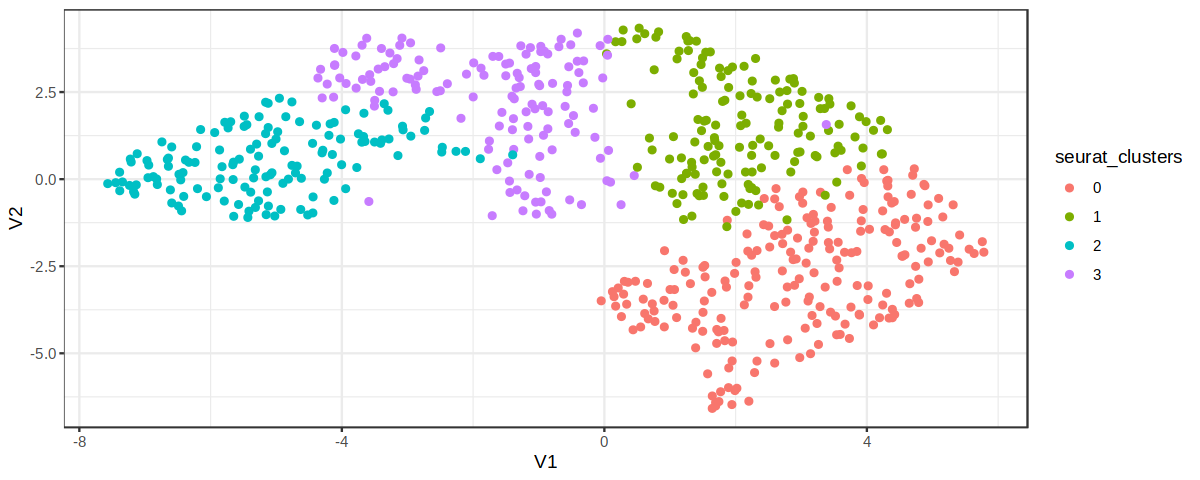

In [50]:
to.plot$seurat_clusters = seurat@meta.data$seurat_clusters
options(repr.plot.height=4, repr.plot.width = 10)
ggplot(to.plot, aes(V1, V2, color = seurat_clusters)) + 
    geom_point() + 
    # scale_color_gradientn(colours = rainbow(3)) + 
    theme_bw()

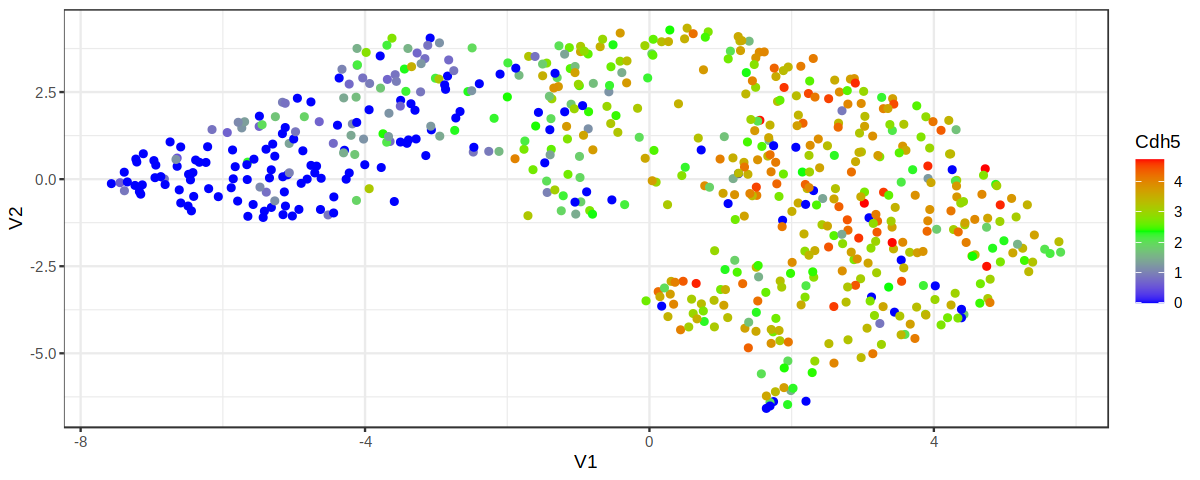

In [51]:
to.plot$gene = as.vector(logcounts(rna.sce['Cdh5',to.plot$cell]))
options(repr.plot.height=4, repr.plot.width = 10)
ggplot(to.plot, aes(V1, V2, color = gene)) + 
    geom_point() + 
    scale_color_gradientn(colours = rev(rainbow(3)), name = 'Cdh5') +
    theme_bw()

In [52]:
subset_markers = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/SS2/Endothelial_subset_markers.txt')

In [53]:
top_markers = subset_markers %>% 
    .[cluster != 'embryo'] %>%
    .[,head(.SD, 10), by = 'cluster'] %>% 
    .[gene %in% rownames(rna.sce)]

In [54]:
to.plot$YS = colMeans(logcounts(rna.sce[top_markers[cluster=='yolk sac', gene]]))
to.plot$allantois = colMeans(logcounts(rna.sce[top_markers[cluster=='allantois', gene]]))
to.plot$embryo = colMeans(logcounts(rna.sce[top_markers[cluster=='embryo', gene]]))

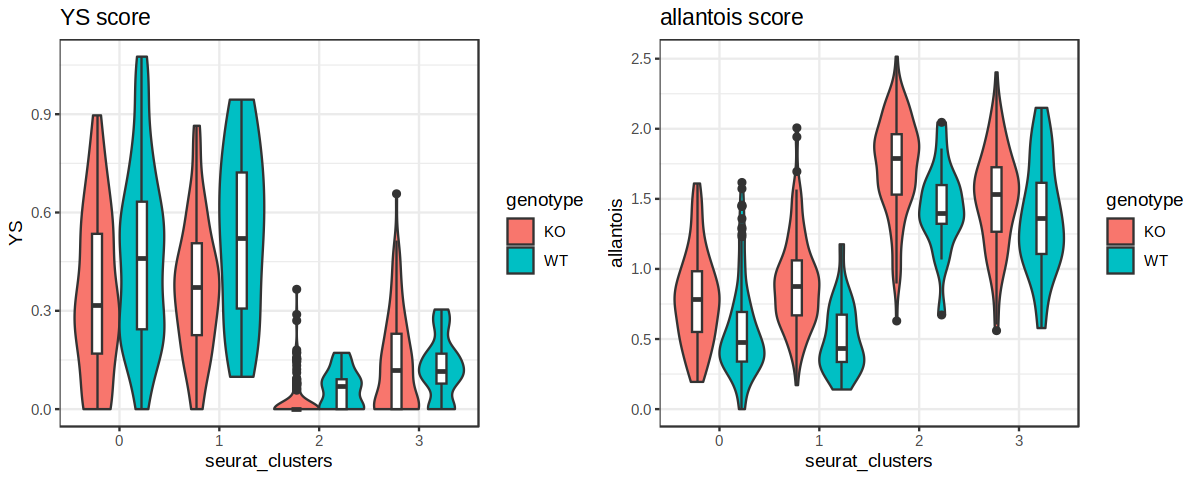

In [55]:
p1 = ggplot(to.plot, aes(seurat_clusters, YS, fill = genotype)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2, fill = 'white', aes(group = interaction(seurat_clusters, genotype)),
                 position = position_dodge(width = 0.9) ) + 
    ggtitle('YS score') +
    theme_bw()

p2 = ggplot(to.plot, aes(seurat_clusters, allantois, fill = genotype)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2, fill = 'white', aes(group = interaction(seurat_clusters, genotype)),
                 position = position_dodge(width = 0.9) ) + 
    ggtitle('allantois score') +
    theme_bw()

ggarrange(p1, p2)

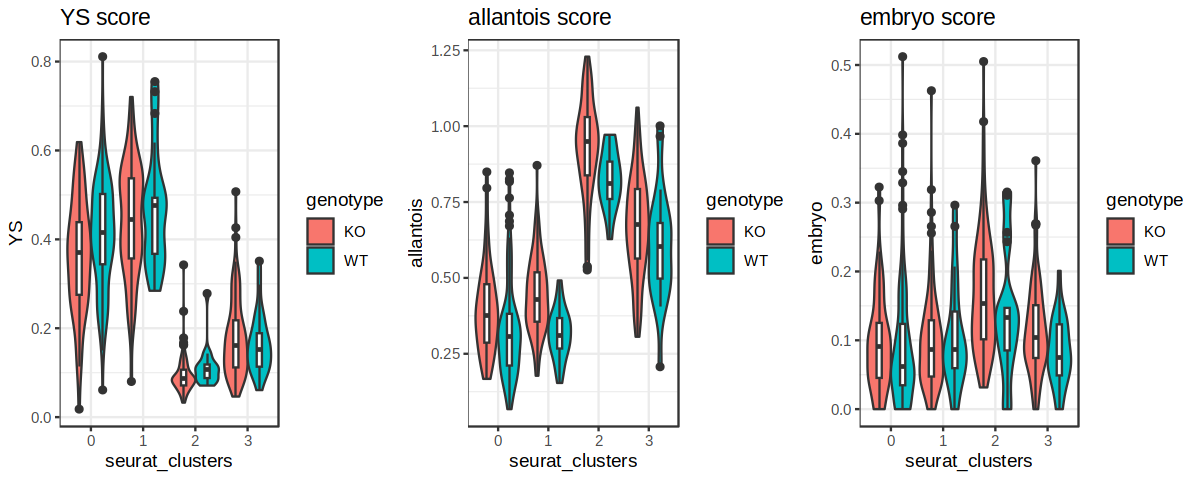

In [59]:
top_markers = subset_markers %>% 
    #.[cluster != 'embryo'] %>%
    .[,head(.SD, 1000), by = 'cluster'] %>% 
    .[gene %in% rownames(rna.sce)]

to.plot$YS = colMeans(logcounts(rna.sce[top_markers[cluster=='yolk sac', gene]]))
to.plot$allantois = colMeans(logcounts(rna.sce[top_markers[cluster=='allantois', gene]]))
to.plot$embryo = colMeans(logcounts(rna.sce[top_markers[cluster=='embryo', gene]]))

p1 = ggplot(to.plot, aes(seurat_clusters, YS, fill = genotype)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2, fill = 'white', aes(group = interaction(seurat_clusters, genotype)),
                 position = position_dodge(width = 0.9) ) + 
    ggtitle('YS score') +
    theme_bw()

p2 = ggplot(to.plot, aes(seurat_clusters, allantois, fill = genotype)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2, fill = 'white', aes(group = interaction(seurat_clusters, genotype)),
                 position = position_dodge(width = 0.9) ) + 
    ggtitle('allantois score') +
    theme_bw()

p3 = ggplot(to.plot, aes(seurat_clusters, embryo, fill = genotype)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2, fill = 'white', aes(group = interaction(seurat_clusters, genotype)),
                 position = position_dodge(width = 0.9) ) + 
    ggtitle('embryo score') +
    theme_bw()

ggarrange(p1, p2, p3, nrow = 1)

In [24]:
Idents(seurat) = seurat@meta.data$genotype

In [25]:
DEGs = as.data.table(FindMarkers(seurat[,seurat@meta.data$seurat_clusters %in% c(0, 1)],
                                 ident.1 = 'KO', ident.2 = 'WT', 
                                 logfc.threshold = 0.25),
                     keep.rownames = T) %>%
    setnames('rn', 'gene')

In [26]:
head(DEGs[p_val_adj < 0.05][order(-avg_log2FC)])

gene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Dlk1,5.479831e-16,0.7830532,0.708,0.293,2.739915e-13
Cldn5,1.264401e-13,0.6661386,0.744,0.365,6.322006e-11
Piezo2,8.803425e-10,0.6505090,0.615,0.329,4.401713e-07
Adam12,3.061000e-17,0.5766509,0.918,0.665,1.530500e-14
Hecw2,1.425973e-09,0.5713300,0.708,0.401,7.129865e-07
Mirg,2.220757e-10,0.5474475,0.615,0.269,1.110379e-07


In [27]:
head(DEGs[p_val_adj < 0.05][order(avg_log2FC)], 20)

gene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Hbb-bh1,4.896217e-57,-1.9135793,0.015,0.868,2.448108e-54
Hba-x,1.545945e-43,-1.7463040,0.000,0.701,7.729727e-41
Hba-a1,1.139059e-35,-1.1963335,0.000,0.599,5.695293e-33
Il31ra,5.706833e-18,-0.8869450,0.344,0.659,2.853417e-15
Runx1,8.596551e-16,-0.8770650,0.251,0.611,4.298275e-13
Kcnq5,1.538037e-13,-0.8418804,0.313,0.659,7.690184e-11
Slc1a3,3.009125e-14,-0.7839300,0.041,0.341,1.504562e-11
Plxnc1,5.368387e-15,-0.7346617,0.364,0.689,2.684194e-12
Rspo3,4.835751e-13,-0.7046933,0.415,0.701,2.417875e-10


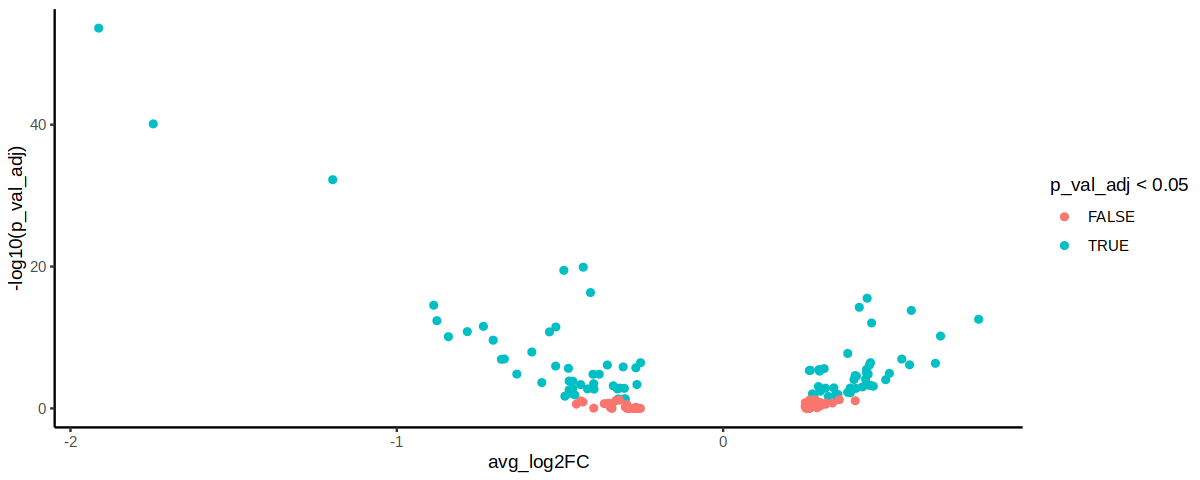

In [28]:
ggplot(DEGs, aes(avg_log2FC, -log10(p_val_adj), col = p_val_adj < 0.05)) + 
    geom_point() + 
    theme_classic()

In [29]:
ArchRProject = loadArchRProject(io$archR.directory)[meta$cell]

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [30]:
ArchRProject <- addCellColData(ArchRProj = ArchRProject, 
                                    data = as.character(seurat@meta.data$seurat_clusters),
                                    cells = colnames(seurat),
                                    name = "seurat_clusters",
                                    force=TRUE)

ArchRProject <- addCellColData(ArchRProj = ArchRProject, 
                                    data = as.character(seurat@meta.data$genotype),
                                    cells = colnames(seurat),
                                    name = "genotype",
                                    force=TRUE)

Overriding previous entry for genotype



In [31]:
# Differential ChromVAR one v all
diffMotif <- getMarkerFeatures(
    ArchRProj = ArchRProject[seurat@meta.data$seurat_clusters %in% c(0, 1)],
    groupBy = 'genotype', 
    useGroups = 'KO', 
    bgdGroups = 'WT',
    testMethod = "wilcoxon",
    binarize = FALSE,
    useMatrix = "silicoChIP_CISBP_v2",
    useSeqnames="z",
    verbose = F
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-1a8bfd2efc7852-Date-2024-12-06_Time-10-18-29.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Assays.Matrix

Pairwise Test KO : Seqnames z

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-1a8bfd2efc7852-Date-2024-12-06_Time-10-18-29.log



In [32]:
diffMotif

class: SummarizedExperiment 
dim: 534 1 
metadata(2): MatchInfo Params
assays(6): Mean FDR ... AUC MeanBGD
rownames(534): 1 2 ... 533 534
rowData names(3): seqnames idx name
colnames(1): KO
colData names(0):

In [33]:
diffMotif.dt = lapply(colnames(diffMotif), function(x){
    tmp = data.table(motif = str_split(rowData(diffMotif)$name, '_') %>% map_chr(1),
                                  FDR = assay(diffMotif[,x], 'FDR')[[1]],
                                  MeanDiff = assay(diffMotif[,x], 'MeanDiff')[[1]]) %>% 
                        .[order(-MeanDiff)] %>% 
                        .[,mofa_cluster := x]
    return(tmp)
}) %>% rbindlist()

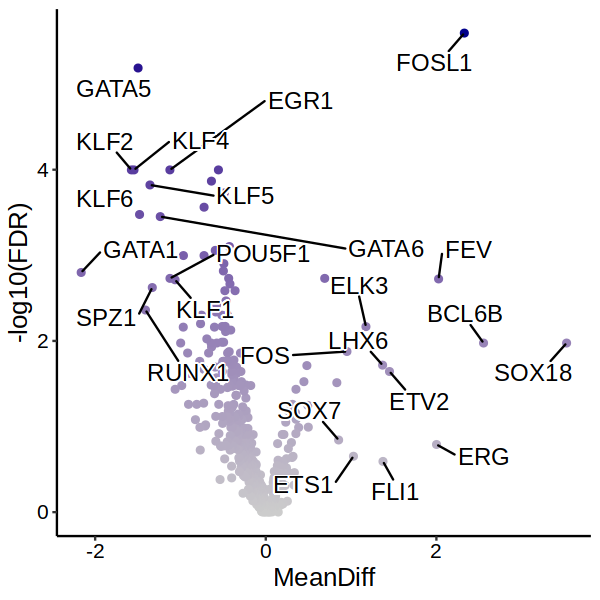

In [34]:
p = ggplot(diffMotif.dt, aes(MeanDiff, -log10(FDR), label=motif)) +
    geom_point(aes(col = -log10(FDR))) +
    scale_color_gradient(low='gray80', high='darkblue', name = '-log10(FDR)') + 
    ggrepel::geom_text_repel(data=diffMotif.dt[MeanDiff>0] %>% 
                                    .[,head(.SD, 12)],
                        aes(x=MeanDiff, y=-log10(FDR)), 
                         max.overlaps=Inf, 
                         box.padding = 0.8,
                         bg.color='white', 
                         bg.r = 0.1,
                         size=5) +
    ggrepel::geom_text_repel(data=diffMotif.dt[MeanDiff<0] %>% 
                                    .[,tail(.SD, 12)],
                        aes(x=MeanDiff, y=-log10(FDR)), 
                         max.overlaps=Inf, 
                         box.padding = 0.8,
                         bg.color='white', 
                         bg.r = 0.1,
                         size=5) +
    theme_classic() +
    theme(
    axis.text = element_text(color='black'),
    # axis.title = element_text(size=rel(1.0), color='black'),
    strip.text = element_text(size=10),
    text=element_text(size=15),
    legend.position="none"
    ) 
options(repr.plot.width=5, repr.plot.height=5)
p

In [69]:
table(seurat@meta.data[seurat@meta.data$seurat_clusters %in% c(0, 1),]$genotype)


 KO  WT 
195 167 

In [35]:
# Differential ChromVAR one v all
diffPeaks <- getMarkerFeatures(
    ArchRProj = ArchRProject[seurat@meta.data$seurat_clusters %in% c(0, 1)],
    groupBy = 'genotype', 
    useGroups = 'WT', 
    bgdGroups = 'KO',
    testMethod = "binomial",
    binarize = TRUE,
    useMatrix = "PeakMatrix",
    verbose = F
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-1a8bfd2a3e5b6b-Date-2024-12-06_Time-10-18-39.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Integer.Matrix

Pairwise Test WT : Seqnames chr1

Pairwise Test WT : Seqnames chr10

Pairwise Test WT : Seqnames chr11

Pairwise Test WT : Seqnames chr12

Pairwise Test WT : Seqnames chr13

Pairwise Test WT : Seqnames chr14

Pairwise Test WT : Seqnames chr15

Pairwise Test WT : Seqnames chr16

Pairwise Test WT : Seqnames chr17

Pairwise Test WT : Seqnames chr18

Pairwise Test WT : Seqnames chr19

Pairwise Test WT : Seqnames chr2

Pairwise Test WT : Seqnames chr3

Pairwise Test WT : Seqnames chr4

Pairwise Test WT : Seqnames chr5

Pairwise Test WT : Seqnames chr6

Pairwise Test WT : Seqnames chr7

Pairwise Test WT : Seqnames chr8

Pairwise Test WT : Seqnames chr9

Pairwise Test WT : Seqnames chrX

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-1a8bfd2a3e5b6b-Date-2024-12-06_Time-10-18-39.l

In [36]:
diffPeaks.dt = lapply(colnames(diffPeaks), function(x){
    tmp = data.table(peak = paste0(rowData(diffPeaks)$seqnames, ':', rowData(diffPeaks)$start,'-', rowData(diffPeaks)$end),
                                  FDR = assay(diffPeaks[,x], 'FDR')[[1]],
                                  Log2FC = assay(diffPeaks[,x], 'Log2FC')[[1]]) %>% 
                        .[order(FDR)] %>% 
                        .[,mofa_cluster := x]
    return(tmp)
}) %>% rbindlist()

Warning message:
“Removed 3204 rows containing missing values (`geom_point()`).”


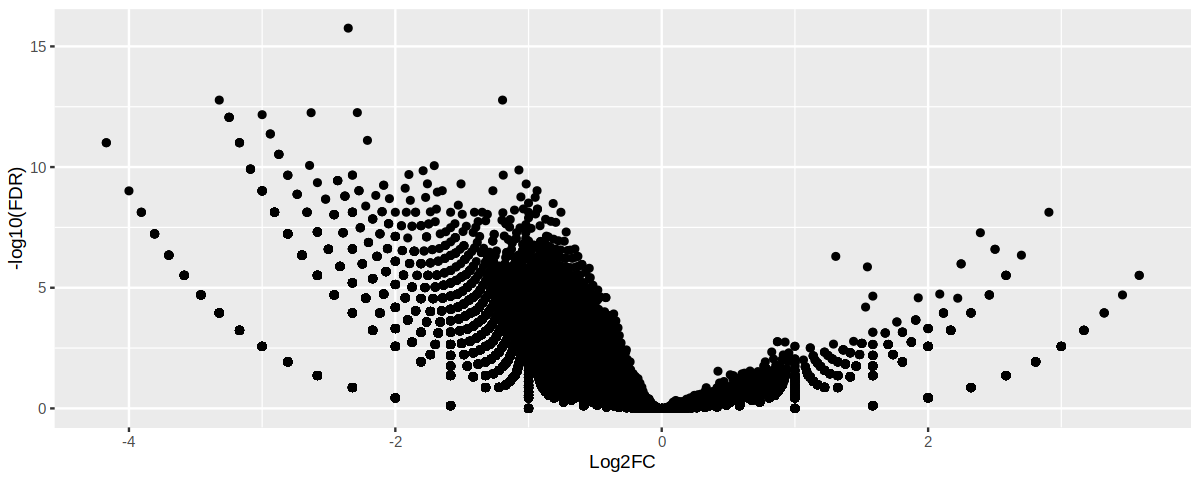

In [67]:
ggplot(diffPeaks.dt, aes(Log2FC, -log10(FDR))) + 
    geom_point()

In [70]:
# Differential ChromVAR one v all
diffPeaks <- getMarkerFeatures(
    ArchRProj = ArchRProject[seurat@meta.data$seurat_clusters %in% c(0, 1)],
    groupBy = 'genotype', 
    useGroups = 'WT', 
    bgdGroups = 'KO',
    testMethod = "wilcoxon",
    binarize = FALSE,
    useMatrix = "PeakMatrix",
    verbose = F
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-1a8bfd3023b656-Date-2024-12-06_Time-17-23-37.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Integer.Matrix

Pairwise Test WT : Seqnames chr1

Pairwise Test WT : Seqnames chr10

Pairwise Test WT : Seqnames chr11

Pairwise Test WT : Seqnames chr12

Pairwise Test WT : Seqnames chr13

Pairwise Test WT : Seqnames chr14

Pairwise Test WT : Seqnames chr15

Pairwise Test WT : Seqnames chr16

Pairwise Test WT : Seqnames chr17

Pairwise Test WT : Seqnames chr18

Pairwise Test WT : Seqnames chr19

Pairwise Test WT : Seqnames chr2

Pairwise Test WT : Seqnames chr3

Pairwise Test WT : Seqnames chr4

Pairwise Test WT : Seqnames chr5

Pairwise Test WT : Seqnames chr6

Pairwise Test WT : Seqnames chr7

Pairwise Test WT : Seqnames chr8

Pairwise Test WT : Seqnames chr9

Pairwise Test WT : Seqnames chrX

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-1a8bfd3023b656-Date-2024-12-06_Time-17-23-37.l

In [71]:
diffPeaks.dt = lapply(colnames(diffPeaks), function(x){
    tmp = data.table(peak = paste0(rowData(diffPeaks)$seqnames, ':', rowData(diffPeaks)$start,'-', rowData(diffPeaks)$end),
                                  FDR = assay(diffPeaks[,x], 'FDR')[[1]],
                                  Log2FC = assay(diffPeaks[,x], 'Log2FC')[[1]]) %>% 
                        .[order(FDR)] %>% 
                        .[,mofa_cluster := x]
    return(tmp)
}) %>% rbindlist()

Warning message:
“Removed 3204 rows containing missing values (`geom_point()`).”


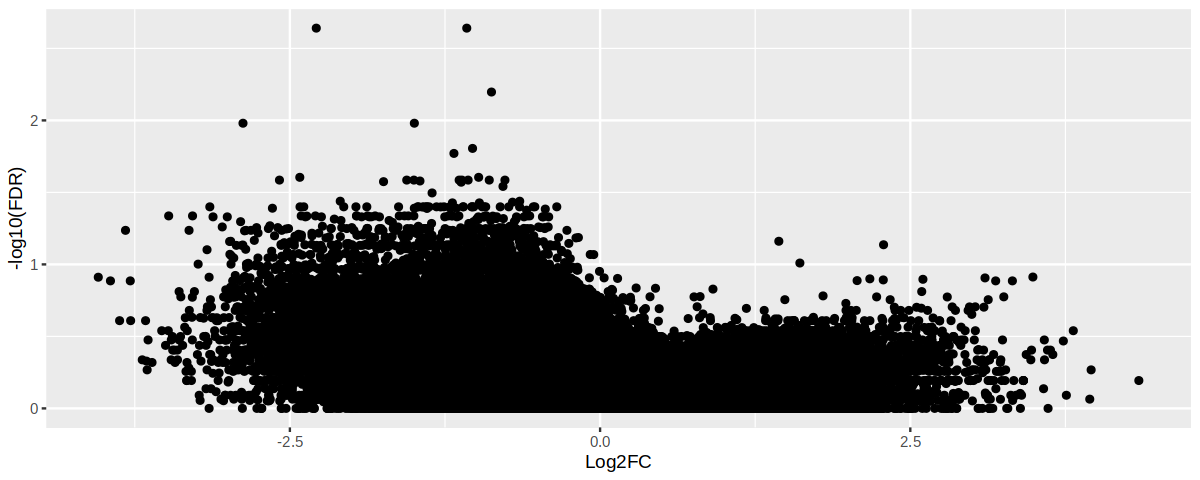

In [72]:
ggplot(diffPeaks.dt, aes(Log2FC, -log10(FDR))) + 
    geom_point()

In [66]:
head(diffPeaks.dt)

peak,FDR,Log2FC,mofa_cluster
<chr>,<dbl>,<dbl>,<chr>
chr1:178597679-178598279,1.752071e-16,-2.353637,WT
chr2:30264956-30265556,1.677014e-13,-3.321928,WT
chr6:47877288-47877888,1.677014e-13,-1.195016,WT
chr11:90220647-90221247,5.534947e-13,-2.285402,WT
chr14:63427517-63428117,5.587579e-13,-2.632268,WT
chr12:39987869-39988469,6.752139e-13,-3.000000,WT


In [37]:
diffPeaks.dt[FDR < 1e-5][order(Log2FC)]

peak,FDR,Log2FC,mofa_cluster
<chr>,<dbl>,<dbl>,<chr>
chr12:109519305-109519905,9.809215e-12,-4.169925,WT
chr13:20471635-20472235,9.809215e-12,-4.169925,WT
chr2:12002153-12002753,9.692025e-10,-4.000000,WT
chr16:24206970-24207570,7.459581e-09,-3.906891,WT
chr17:49189676-49190276,7.459581e-09,-3.906891,WT
chr3:51590377-51590977,7.459581e-09,-3.906891,WT
chr1:126033517-126034117,5.850148e-08,-3.807355,WT
chr1:184716021-184716621,5.850148e-08,-3.807355,WT
chr1:190972520-190973120,5.850148e-08,-3.807355,WT
